In [8]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

# 데이터 경로 설정
file_path = r'C:\Users\EL069\Project\safebooru\data\parquet\danbooru.parquet'

# 메모리 절약을 위해 샘플링하거나 필요한 컬럼만 로드 (예: tag, rating, score 등)
# 4GB 파일이므로 전체 로드보다는 스캔(Scan) 방식을 권장합니다.
lazy_df = pl.scan_parquet(file_path)

# 시각화를 위해 상위 100,000개의 데이터만 샘플로 가져오기
df = lazy_df.head(100000).collect().to_pandas()

C:\Users\EL069\AppData\Local\Temp\ipykernel_11488\782980613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


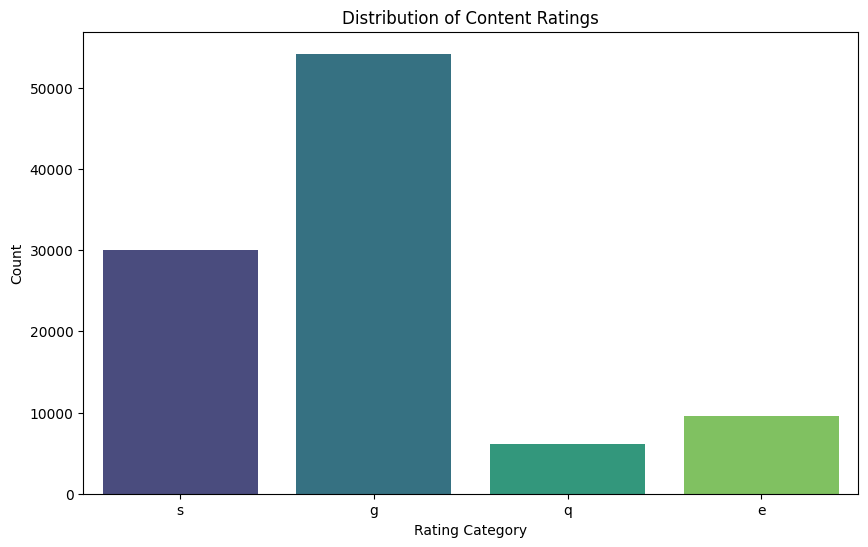

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.show()

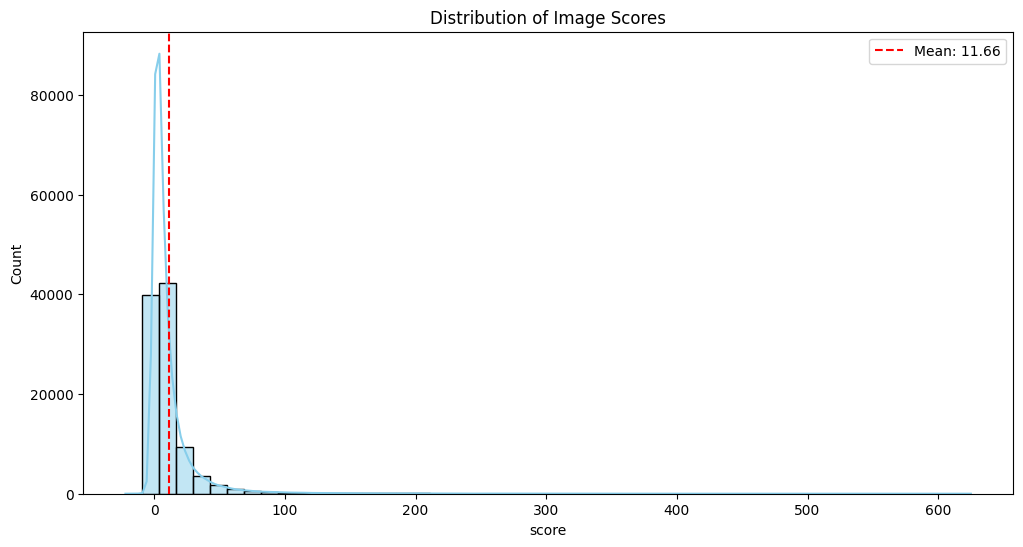

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df['score'], bins=50, kde=True, color='skyblue')
plt.axvline(df['score'].mean(), color='red', linestyle='--', label=f'Mean: {df[ "score"].mean():.2f}')
plt.title('Distribution of Image Scores')
plt.legend()
plt.show()

C:\Users\EL069\AppData\Local\Temp\ipykernel_11488\2430521021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, x='Count', y='Tag', palette='magma')


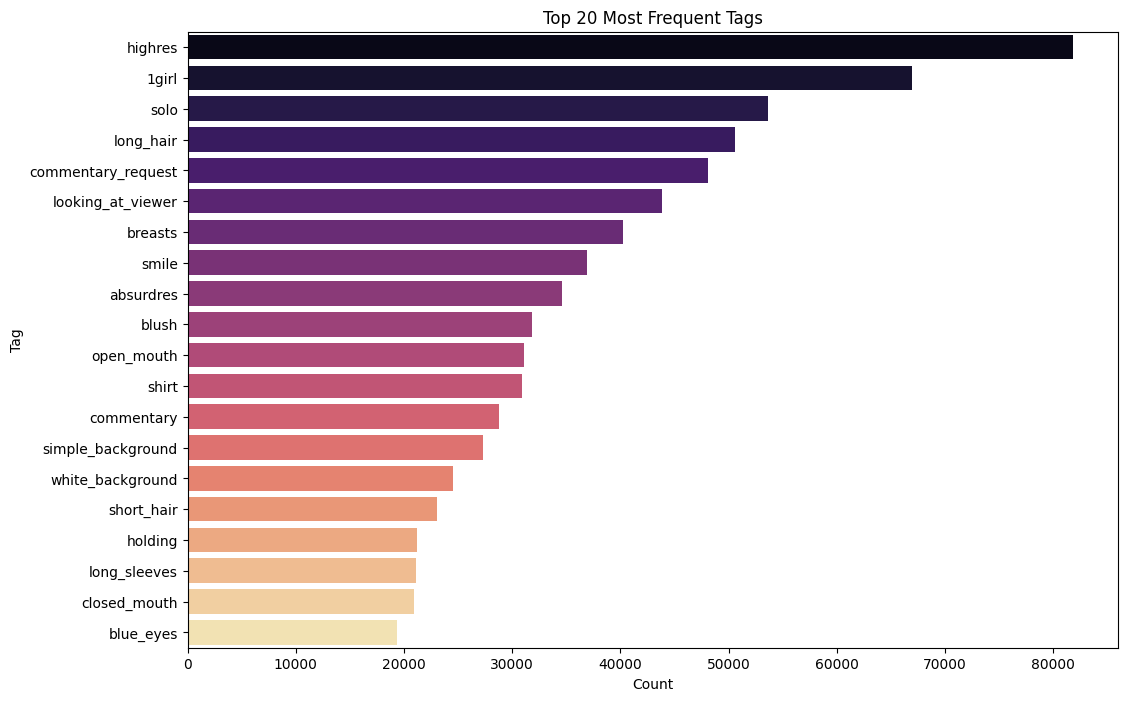

In [11]:
from collections import Counter

# 모든 태그를 리스트로 분리하여 빈도 계산
all_tags = " ".join(df['tag_string'].astype(str)).split()
tag_counts = Counter(all_tags).most_common(20)
tag_df = pd.DataFrame(tag_counts, columns=['Tag', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=tag_df, x='Count', y='Tag', palette='magma')
plt.title('Top 20 Most Frequent Tags')
plt.show()

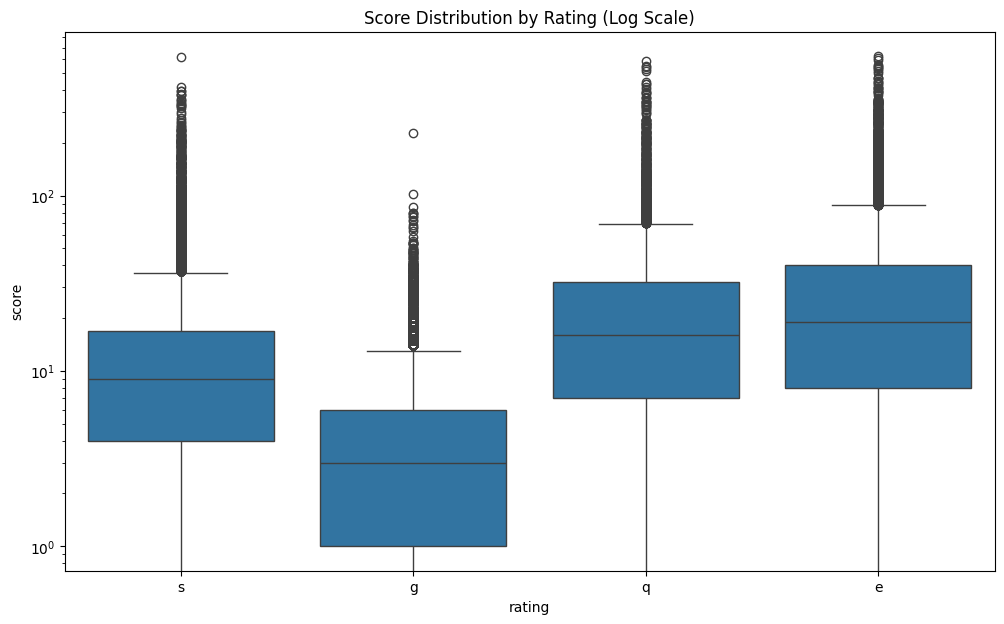

In [12]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='rating', y='score')
plt.yscale('log') # 스코어 편차가 클 경우 로그 스케일 적용
plt.title('Score Distribution by Rating (Log Scale)')
plt.show()

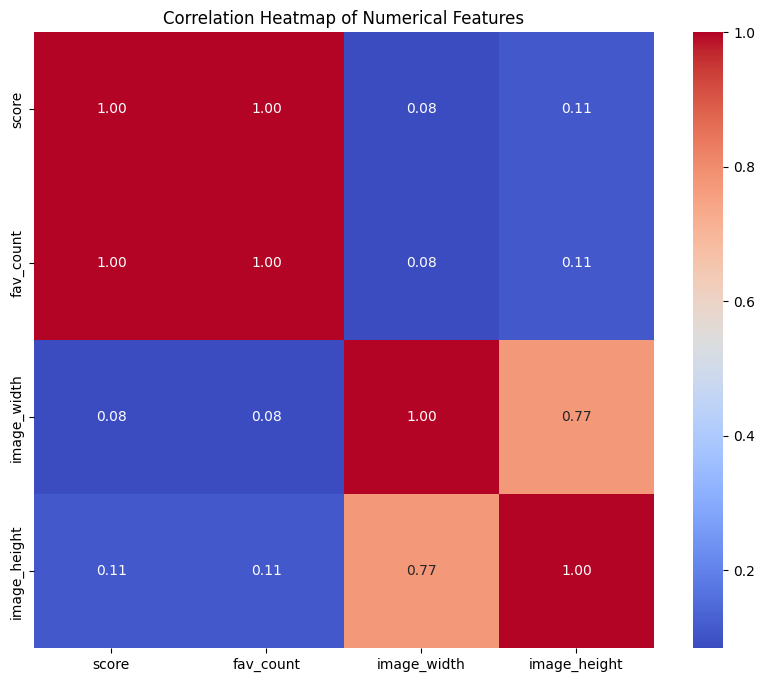

In [13]:
plt.figure(figsize=(10, 8))
corr = df[['score', 'fav_count', 'image_width', 'image_height']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()